# PCA analysis of molecular chemical space

This notebook explores dimensionality reduction and chemical space visualization using molecular descriptors and Principal Component Analysis (PCA).

In [1]:
#install rdkit
!pip install rdkit

#import
from rdkit import Chem
from rdkit.Chem import Descriptors

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#dataset
molecules = {
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(O)C=C1",
    "Naproxen": "COC1=CC=CC=C1C(C)C(=O)O",
    "Lidocaine": "CCN(CC)CCNC(=O)C1=CC=CC=C1"
}

In [3]:
#descriptors
data = []

for name, smiles in molecules.items():
    
    mol = Chem.MolFromSmiles(smiles)

    descriptors = {
        "Molecule": name,
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HDonors": Descriptors.NumHDonors(mol),
        "HAcceptors": Descriptors.NumHAcceptors(mol)
    }

    data.append(descriptors)

df = pd.DataFrame(data)

df

,Molecule,MolWt,LogP,TPSA,HDonors,HAcceptors
0,Caffeine,194.194,-1.0293,61.82,0,6
1,Aspirin,180.159,1.3101,63.60,1,3
2,Ibuprofen,206.285,3.0732,37.30,1,1
3,Paracetamol,151.165,1.3506,49.33,2,2
4,Naproxen,180.203,1.8833,46.53,1,2
5,Lidocaine,220.316,1.7582,32.34,1,2


In [4]:
#pca
X = df.drop(columns="Molecule")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df["Molecule"] = df["Molecule"]

pca_df

,PC1,PC2,Molecule
0,3.481059,0.660544,Caffeine
1,0.780564,-0.774726,Aspirin
2,-1.825872,0.994649,Ibuprofen
3,-0.801731,-2.261569,Paracetamol
4,-0.512917,-0.235755,Naproxen
5,-1.121101,1.616857,Lidocaine


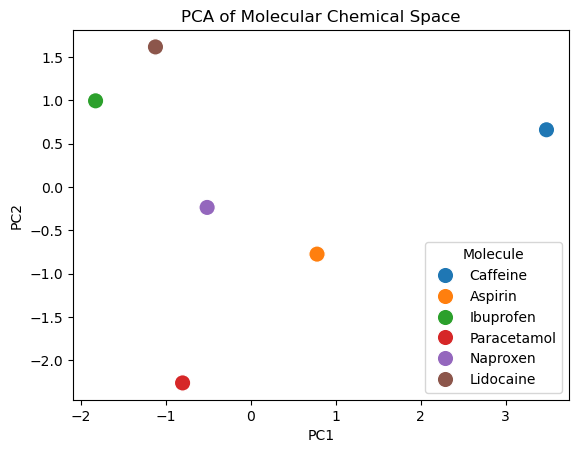

In [5]:
#pca visualization
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Molecule",
    s=140
)

plt.title("PCA of Molecular Chemical Space")

plt.show()

## PCA interpretation

PCA enables dimensionality reduction of molecular descriptor datasets while preserving relevant variance. The resulting chemical space representation highlights similarities and differences between compounds according to physicochemical properties.

This type of analysis is commonly applied in cheminformatics and early-stage drug discovery workflows.

## Why PCA is useful

Principal Component Analysis (PCA) reduces multidimensional datasets into lower-dimensional representations that facilitate visualization and interpretation of complex molecular property relationships.